In [1]:
# COMPLETE SETUP CELL - Run this FIRST

from google.colab import drive
import os

# Mount Drive (skip if already mounted)
try:
    drive.mount('/content/drive', force_remount=False)
except:
    pass  # Already mounted

# Navigate to project folder
# Update this path to match your project location in Google Drive
project_path = '/content/drive/MyDrive/DLP_project'  # Change this to your actual path
os.chdir(project_path)

# Change to notebooks folder (so ../results/ and ../data/ paths work)
os.chdir('notebooks')

print(f"Current directory: {os.getcwd()}")
print(f"Can access data/processed: {os.path.exists('../data/processed')}")
print(f"Can access results: {os.path.exists('../results')}")


Mounted at /content/drive
Current directory: /content/drive/MyDrive/DLP_project/notebooks
Can access data/processed: True
Can access results: True


# LSTM Training

This notebook trains LSTM models for Urdu poetry generation using three different optimizers: Adam, RMSprop, and SGD.


In [2]:
# Install required libraries
!pip install -q tensorflow numpy pandas matplotlib


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import pickle
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.callbacks import EarlyStopping

# Set random seeds for reproducibility
np.random.seed(42)
import tensorflow as tf
tf.random.set_seed(42)

# Create directories
os.makedirs('results', exist_ok=True)


## Load Processed Data


In [4]:
# Load processed data
X_train = np.load('../data/processed/X_train.npy')
y_train = np.load('../data/processed/y_train.npy')
X_val = np.load('../data/processed/X_val.npy')
y_val = np.load('../data/processed/y_val.npy')
X_test = np.load('../data/processed/X_test.npy')
y_test = np.load('../data/processed/y_test.npy')

# Load tokenizer and metadata
with open('../data/processed/tokenizer.pkl', 'rb') as f:
    tokenizer = pickle.load(f)

with open('../data/processed/metadata.pkl', 'rb') as f:
    metadata = pickle.load(f)

vocab_size = metadata['vocab_size']
sequence_length = metadata['sequence_length']

print(f"Data loaded successfully!")
print(f"Vocabulary size: {vocab_size}")
print(f"Sequence length: {sequence_length}")
print(f"Train samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples: {len(X_test)}")


Data loaded successfully!
Vocabulary size: 10505
Sequence length: 20
Train samples: 16865
Validation samples: 2108
Test samples: 2109


## Build LSTM Model


In [5]:
def build_lstm_model(vocab_size, sequence_length, embedding_dim=128, lstm_units=256):
    """Build an LSTM model for next-word prediction"""
    model = Sequential([
        Embedding(vocab_size, embedding_dim, input_length=sequence_length),
        LSTM(lstm_units, return_sequences=False),
        Dense(vocab_size, activation='softmax')
    ])
    return model

# Hyperparameters
EMBEDDING_DIM = 128
LSTM_UNITS = 256
BATCH_SIZE = 128
EPOCHS = 25
LEARNING_RATE = 0.001

print("Model architecture defined!")


Model architecture defined!


## Training Function


In [6]:
def train_model(optimizer_name, optimizer):
    """Train LSTM model with specified optimizer"""
    print(f"\n{'='*60}")
    print(f"Training LSTM with {optimizer_name} optimizer")
    print(f"{'='*60}\n")

    # Build model
    model = build_lstm_model(vocab_size, sequence_length, EMBEDDING_DIM, LSTM_UNITS)
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # Early stopping
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )

    # Record start time
    start_time = time.time()

    # Train model
    history = model.fit(
        X_train, y_train,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        validation_data=(X_val, y_val),
        callbacks=[early_stopping],
        verbose=1
    )

    # Record end time
    training_time = time.time() - start_time

    # Evaluate on all sets
    train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
    val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

    # Compute perplexity
    perplexity = np.exp(test_loss)

    # Save model
    model.save(f'../models/lstm_{optimizer_name.lower()}.h5')

    return {
        'model': model,
        'history': history,
        'train_loss': train_loss,
        'val_loss': val_loss,
        'test_loss': test_loss,
        'perplexity': perplexity,
        'training_time': training_time
    }


## Train with Adam Optimizer


In [7]:
os.makedirs('models', exist_ok=True)

adam_optimizer = Adam(learning_rate=LEARNING_RATE)
adam_results = train_model('Adam', adam_optimizer)



Training LSTM with Adam optimizer

Epoch 1/25


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


132/132 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.1123 - loss: 7.0972 - val_accuracy: 0.1101 - val_loss: 5.9098
Epoch 2/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.1171 - loss: 5.6259 - val_accuracy: 0.1101 - val_loss: 5.8238
Epoch 3/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.1172 - loss: 5.4481 - val_accuracy: 0.1110 - val_loss: 5.8252
Epoch 4/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.1310 - loss: 5.2893 - val_accuracy: 0.1347 - val_loss: 5.7853
Epoch 5/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.1557 - loss: 5.0964 - val_accuracy: 0.1447 - val_loss: 5.7170
Epoch 6/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.1824 - loss: 4.8906 - val_accuracy: 0.1551 - val_loss: 5.6461
Epoch 7/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.2098 - loss: 4.6560 - val_accuracy: 0.1722 - val_loss: 5.5870
Epoch 8/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.2351 - loss: 4.4176 - val_accuracy: 0.185

## Train with RMSprop Optimizer


In [8]:
rmsprop_optimizer = RMSprop(learning_rate=LEARNING_RATE)
rmsprop_results = train_model('RMSprop', rmsprop_optimizer)



Training LSTM with RMSprop optimizer

Epoch 1/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.1123 - loss: 7.1676 - val_accuracy: 0.1101 - val_loss: 5.9751
Epoch 2/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.1171 - loss: 5.9165 - val_accuracy: 0.1101 - val_loss: 5.9630
Epoch 3/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.1171 - loss: 5.8975 - val_accuracy: 0.1101 - val_loss: 5.9575
Epoch 4/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.1171 - loss: 5.8887 - val_accuracy: 0.1101 - val_loss: 5.9537
Epoch 5/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.1171 - loss: 5.8826 - val_accuracy: 0.1101 - val_loss: 5.9505
Epoch 6/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.1171 - loss: 5.8773 - val_accuracy: 0.1101 - val_loss: 5.9458
Epoch 7/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.1171 - loss: 5.8706 - val_accuracy: 0.1101 - val_loss: 5.9348
Epoch 8/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - acc

## Train with SGD Optimizer


In [9]:
sgd_optimizer = SGD(learning_rate=LEARNING_RATE)
sgd_results = train_model('SGD', sgd_optimizer)



Training LSTM with SGD optimizer

Epoch 1/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.0349 - loss: 9.2588 - val_accuracy: 0.1101 - val_loss: 9.2567
Epoch 2/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.1171 - loss: 9.2559 - val_accuracy: 0.1101 - val_loss: 9.2539
Epoch 3/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.1171 - loss: 9.2530 - val_accuracy: 0.1101 - val_loss: 9.2511
Epoch 4/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.1171 - loss: 9.2501 - val_accuracy: 0.1101 - val_loss: 9.2483
Epoch 5/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.1171 - loss: 9.2472 - val_accuracy: 0.1101 - val_loss: 9.2455
Epoch 6/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.1171 - loss: 9.2443 - val_accuracy: 0.1101 - val_loss: 9.2427
Epoch 7/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.1171 - loss: 9.2414 - val_accuracy: 0.1101 - val_loss: 9.2399
Epoch 8/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 

## Save Results to CSV


In [10]:
# Prepare results
results_data = [
    {
        'model': 'LSTM',
        'optimizer': 'Adam',
        'train_loss': adam_results['train_loss'],
        'val_loss': adam_results['val_loss'],
        'test_loss': adam_results['test_loss'],
        'perplexity': adam_results['perplexity'],
        'training_time': adam_results['training_time']
    },
    {
        'model': 'LSTM',
        'optimizer': 'RMSprop',
        'train_loss': rmsprop_results['train_loss'],
        'val_loss': rmsprop_results['val_loss'],
        'test_loss': rmsprop_results['test_loss'],
        'perplexity': rmsprop_results['perplexity'],
        'training_time': rmsprop_results['training_time']
    },
    {
        'model': 'LSTM',
        'optimizer': 'SGD',
        'train_loss': sgd_results['train_loss'],
        'val_loss': sgd_results['val_loss'],
        'test_loss': sgd_results['test_loss'],
        'perplexity': sgd_results['perplexity'],
        'training_time': sgd_results['training_time']
    }
]

# Create or append to results.csv
df = pd.DataFrame(results_data)
if os.path.exists('../results/results.csv'):
    existing_df = pd.read_csv('../results/results.csv')
    df = pd.concat([existing_df, df], ignore_index=True)
df.to_csv('../results/results.csv', index=False)

print("Results saved to results/results.csv")
print("\nResults Summary:")
print(df.to_string(index=False))


Results saved to results/results.csv

Results Summary:
model optimizer  train_loss  val_loss  test_loss  perplexity  training_time
  RNN      Adam    3.616657  5.308016   5.263339  193.125269      22.809120
  RNN   RMSprop    3.318506  4.965223   4.934547  139.010216      53.675207
  RNN       SGD    6.767591  6.800785   6.752016  855.782339      34.678181
 LSTM      Adam    3.933584  5.549473   5.459606  235.004742      31.366117
 LSTM   RMSprop    4.878351  5.369602   5.291675  198.675852      42.872937
 LSTM       SGD    9.186385  9.188443   9.185021 9749.988655      35.316387


## Training & Validation Loss Curves


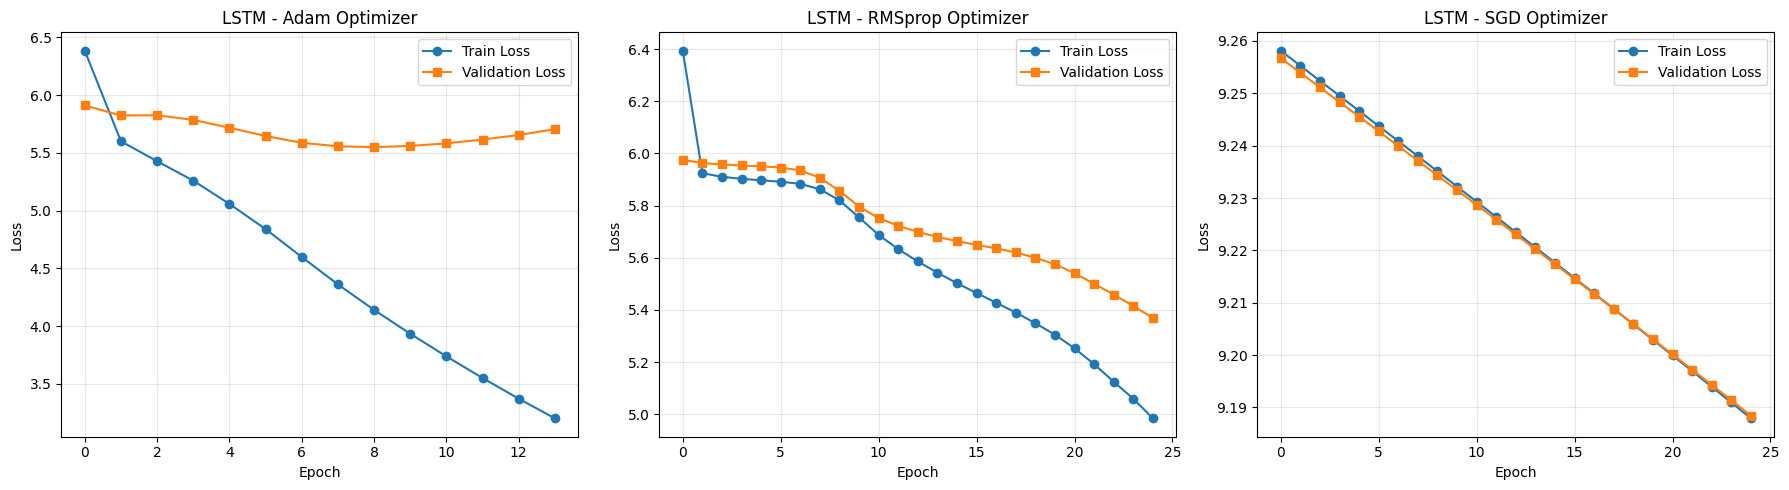

In [11]:
# Plot loss curves for all optimizers
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

optimizers = ['Adam', 'RMSprop', 'SGD']
results_list = [adam_results, rmsprop_results, sgd_results]

for idx, (opt_name, result) in enumerate(zip(optimizers, results_list)):
    history = result['history']
    ax = axes[idx]

    ax.plot(history.history['loss'], label='Train Loss', marker='o')
    ax.plot(history.history['val_loss'], label='Validation Loss', marker='s')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title(f'LSTM - {opt_name} Optimizer')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Final Evaluation Metrics


In [12]:
# Display metrics table
metrics_df = pd.DataFrame({
    'Optimizer': ['Adam', 'RMSprop', 'SGD'],
    'Train Loss': [adam_results['train_loss'], rmsprop_results['train_loss'], sgd_results['train_loss']],
    'Val Loss': [adam_results['val_loss'], rmsprop_results['val_loss'], sgd_results['val_loss']],
    'Test Loss': [adam_results['test_loss'], rmsprop_results['test_loss'], sgd_results['test_loss']],
    'Perplexity': [adam_results['perplexity'], rmsprop_results['perplexity'], sgd_results['perplexity']],
    'Training Time (s)': [adam_results['training_time'], rmsprop_results['training_time'], sgd_results['training_time']]
})

print("=" * 80)
print("LSTM Model - Final Evaluation Metrics")
print("=" * 80)
print(metrics_df.to_string(index=False))
print("=" * 80)


LSTM Model - Final Evaluation Metrics
Optimizer  Train Loss  Val Loss  Test Loss  Perplexity  Training Time (s)
     Adam    3.933584  5.549473   5.459606  235.004742          31.366117
  RMSprop    4.878351  5.369602   5.291675  198.675852          42.872937
      SGD    9.186385  9.188443   9.185021 9749.988655          35.316387
